# Catastrophic Forgetting in Predictive Coding Across Neural Network Architectures

This Jupyter notebook systematically evaluates **Predictive Coding (`jpc`)** in a sequential class-learning experiment on MNIST across three specific architectures:

1. **`784 - 100 - 10`** (1 hidden layer, 100 neurons)
3. **`784 - 1000 - 10`** (1 hidden layer, 1000 neurons)
4. **`784 - 300 - 300 - 10`** (2 hidden layers, 300 neurons each)

## Setup & Data Loading

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch

root_dir = Path.cwd().parent.resolve()
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from src.data import download_mnist
from src.experiments.forgetting import (
    build_forgetting_loaders,
    run_forgetting_experiment
)

def save_experiment_results(results, filepath):
    import json
    p = Path(filepath)
    p.parent.mkdir(parents=True, exist_ok=True)
    with open(p, "w", encoding="utf-8") as f:
        json.dump(results, f, indent=2)

print("Loading MNIST dataset (keep_prop=0.5)...")
train_set, valid_set, test_set = download_mnist()
loaders = build_forgetting_loaders(train_set, valid_set, batch_size=32)
num_epochs = 20
results_history = {}
print("Setup completed successfully!")

Loading MNIST dataset (keep_prop=0.5)...
Number of examples retained:
  48001 (training)
  11999 (validation)
  10000 (test)
Setup completed successfully!


In [2]:
def run_and_plot_architecture(arch_label, num_hidden, num_hidden_layers=1):
    print(f"--- Running Predictive Coding Experiment for Architecture: {arch_label} ---")
    
    # Run Predictive Coding
    pc_res = run_forgetting_experiment(
        train_loader_old=loaders["train_loader_old"],
        valid_loader_old=loaders["valid_loader_old"],
        train_loader_new=loaders["train_loader_new"],
        valid_loader_new=loaders["valid_loader_new"],
        train_loader_full=loaders["train_loader_full"],
        model_type="predictive_coding",
        num_epochs_phase1=num_epochs,
        num_epochs_phase2=num_epochs,
        num_hidden=num_hidden,
        num_hidden_layers=num_hidden_layers,
        lr=1e-3,
        verbose=False,
    )
    
    pc_trace = pc_res["old_class_acc_trace"]
    pc_p1 = float(pc_trace[num_epochs - 1])
    pc_p2 = float(pc_trace[-1])
    pc_new = float(pc_res["new_class_acc_final"])
    
    print(f"Predictive Coding  -> Phase 1 Acc: {pc_p1:.1f}%, Retained Acc: {pc_p2:.1f}%, New Task Acc: {pc_new:.1f}%")
    
    # Plot single curve
    fig, ax = plt.subplots(figsize=(8, 4), dpi=120)
    epochs_axis = np.arange(1, len(pc_trace) + 1)
    
    # Phase shading
    ax.axvspan(0.5, num_epochs + 0.5, color="#e6f2ff", alpha=0.5, label="Phase 1 (Digits 0-5)")
    ax.axvspan(num_epochs + 0.5, len(pc_trace) + 0.5, color="#fff0e6", alpha=0.5, label="Phase 2 (Digits 6-9)")

    ax.plot(epochs_axis, pc_trace, "s-", label=f"Predictive Coding ({arch_label})", color="#d62728", linewidth=2.2, markersize=6)
    ax.axvline(num_epochs + 0.5, color="#7f7f7f", linestyle="--", linewidth=1.2)

    ax.set_title(f"Forgetting Curve: {arch_label}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Training Epoch", fontsize=10)
    ax.set_ylabel("Accuracy on Digits 0-5 (%)", fontsize=10)
    ax.set_xlim(0.5, len(pc_trace) + 0.5)
    ax.set_ylim(-2, 102)
    ax.grid(True, linestyle=":", alpha=0.5)
    ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.95)

    plt.tight_layout()
    plt.show()
    
    res = {
        "p1_acc": pc_p1,
        "retained_acc": pc_p2,
        "new_acc": pc_new,
        "trace": pc_trace,
    }
    results_history[arch_label] = res
    return res

## Section 1: Architecture `784 - 100 - 10`
*Single hidden layer with 100 neurons.*

--- Running Predictive Coding Experiment for Architecture: 784-100-10 ---


100%|██████████| 20/20 [01:16<00:00,  3.82s/it]


Predictive Coding  -> Phase 1 Acc: 98.6%, Retained Acc: 0.0%, New Task Acc: 98.9%


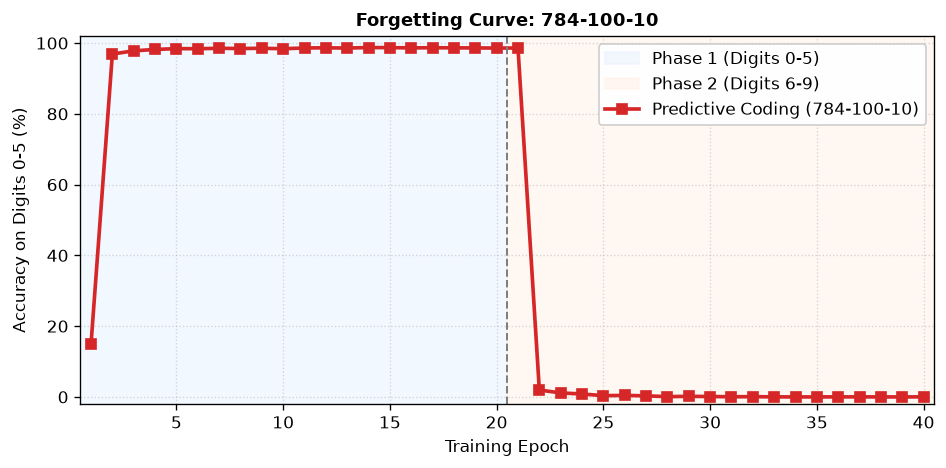

In [3]:
res_100 = run_and_plot_architecture("784-100-10", num_hidden=100, num_hidden_layers=1)

## Section 2: Architecture `784 - 1000 - 10`
*Single hidden layer with 1000 neurons.*

In [ ]:
res_1000 = run_and_plot_architecture("784-1000-10", num_hidden=1000, num_hidden_layers=1)

## Section 3: Architecture `784 - 300 - 300 - 10`
*Two hidden layers with 300 neurons each.*

In [ ]:
res_300_300 = run_and_plot_architecture("784-300-300-10", num_hidden=[300, 300], num_hidden_layers=2)

## Section 4: Summary Table

In [ ]:
from IPython.display import display, Markdown

md_table = """
### Performance Summary Across Architectures (Predictive Coding)

| Architecture | Phase 1 Acc (Digits 0–5) | Retained Acc (Digits 0–5) | New Task Acc (Digits 6–9) |
| :---: | :---: | :---: | :---: |
"""

for arch, data in results_history.items():
    md_table += f"| `{arch}` | **{data['p1_acc']:.1f}%** | **{data['retained_acc']:.1f}%** | **{data['new_acc']:.1f}%** |\n"

display(Markdown(md_table))

out_file = root_dir / "data" / "results" / "notebook_architecture_results.json"
save_experiment_results(results_history, str(out_file))
print(f"Results successfully saved to {out_file}")